# 07 Block Group Classification (Fixed)

分析55个排除区块 + 1283个分析区块的用地分类

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "./finaldata"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_data")
EXPORT_DIR = os.path.join(DATA_DIR, "arcgis_export")
os.makedirs(EXPORT_DIR, exist_ok=True)

print("✅ Setup complete")

✅ Setup complete


## 1. Load Data

In [2]:
# Load data
gdf_full = gpd.read_file(os.path.join(PROCESSED_DIR, "philly_integrated_data.shp"))
gdf_analysis = gpd.read_file(os.path.join(PROCESSED_DIR, "final_analysis_with_predictions.shp"))

print(f"Full: {len(gdf_full)} | Analysis: {len(gdf_analysis)} | Excluded: {len(gdf_full)-len(gdf_analysis)}")

Full: 1338 | Analysis: 1283 | Excluded: 55


## 2. Identify & Classify Excluded Blocks

In [3]:
# Find excluded
excluded_geoids = set(gdf_full['GEOID']) - set(gdf_analysis['GEOID'])
gdf_excluded = gdf_full[gdf_full['GEOID'].isin(excluded_geoids)].copy()

# Calculate area
gdf_excluded['area_km2'] = gdf_excluded['ALAND'] / 1_000_000
gdf_analysis['area_km2'] = gdf_analysis['ALAND'] / 1_000_000

print(f"✅ Found {len(gdf_excluded)} excluded blocks")
print(f"   Avg area: {gdf_excluded['area_km2'].mean():.3f} km² (vs {gdf_analysis['area_km2'].mean():.3f} km² for analysis)")

✅ Found 55 excluded blocks
   Avg area: 1.170 km² (vs 0.221 km² for analysis)


In [4]:
# Classify excluded blocks
def classify_excluded(row):
    area = row['area_km2']
    pop = row.get('population', 0) or 0
    
    if area > 2 and pop == 0:
        return 'Airport/Major Facility'
    elif area > 1 and pop == 0:
        return 'Park/Open Space'
    elif pop == 0:
        return 'Industrial/Commercial'
    elif pd.isna(row.get('median_inc')):
        return 'Institutional'
    else:
        return 'Other Non-Residential'

gdf_excluded['land_use'] = gdf_excluded.apply(classify_excluded, axis=1)

print("\nExcluded Block Classification:")
land_use_counts = gdf_excluded['land_use'].value_counts()
for cat, count in land_use_counts.items():
    print(f"  {cat}: {count}")


Excluded Block Classification:
  Industrial/Commercial: 18
  Institutional: 17
  Park/Open Space: 13
  Airport/Major Facility: 7


## 3. Classify Analysis Blocks by Density

In [5]:
# Population density classification
if 'population' in gdf_analysis.columns:
    gdf_analysis['pop_density'] = gdf_analysis['population'] / gdf_analysis['area_km2']
    
    def classify_density(d):
        if pd.isna(d) or d < 500:
            return 'Mixed Use'
        elif d < 1500:
            return 'Low Density'
        elif d < 4000:
            return 'Low-Medium'
        elif d < 8000:
            return 'Medium'
        elif d < 15000:
            return 'Medium-High'
        else:
            return 'High Density'
    
    gdf_analysis['land_use'] = gdf_analysis['pop_density'].apply(classify_density)
    
    print("Analysis Block Classification:")
    for cat in ['High Density', 'Medium-High', 'Medium', 'Low-Medium', 'Low Density', 'Mixed Use']:
        count = (gdf_analysis['land_use'] == cat).sum()
        if count > 0:
            print(f"  {cat}: {count}")
else:
    gdf_analysis['land_use'] = 'Residential'
    print("No population column - all marked as Residential")

No population column - all marked as Residential


## 4. Visualization

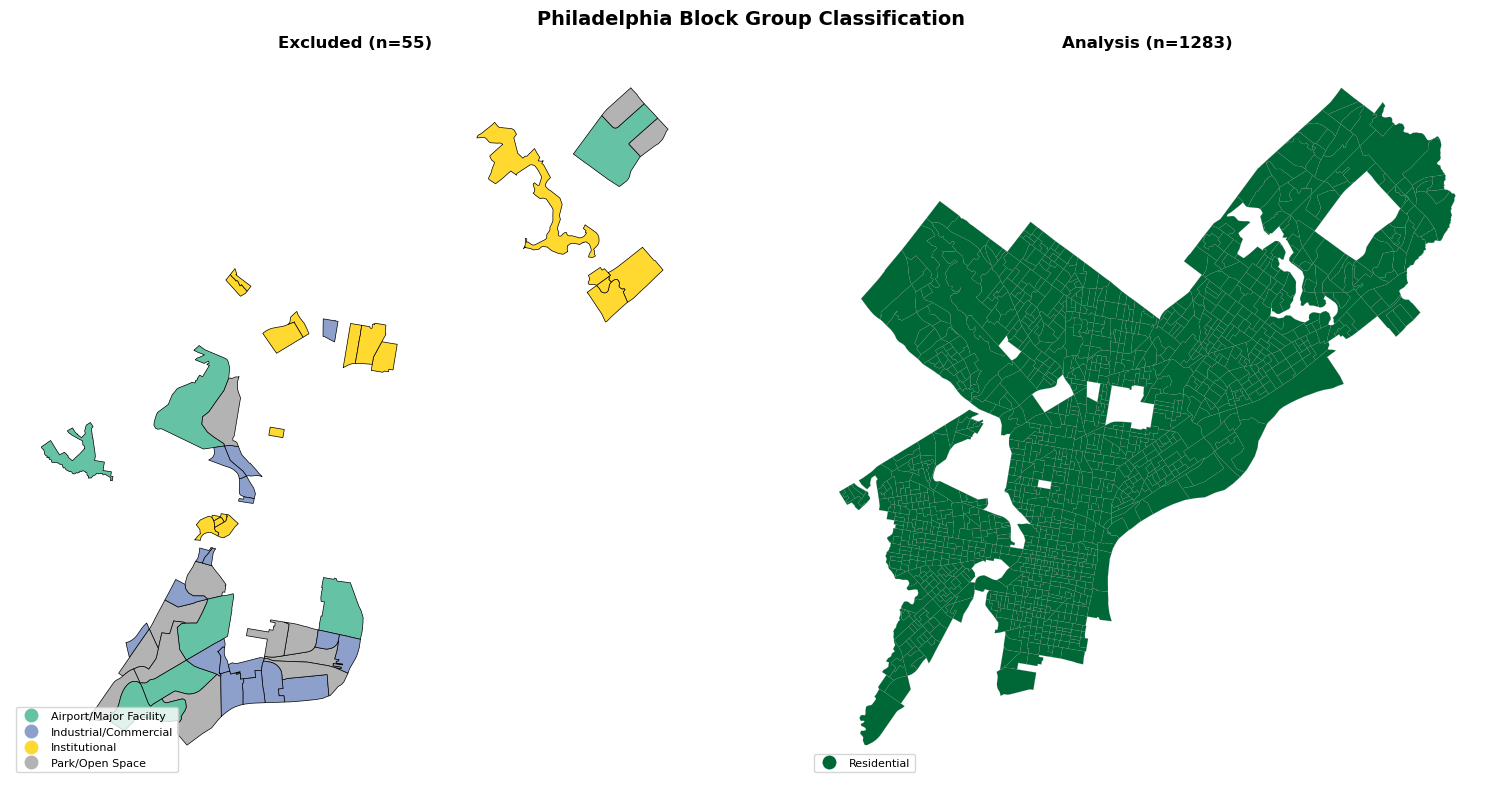

✅ Saved: land_use_classification.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Excluded
gdf_excluded.plot(column='land_use', ax=axes[0], legend=True,
                  categorical=True, cmap='Set2',
                  edgecolor='black', linewidth=0.5,
                  legend_kwds={'loc': 'lower left', 'fontsize': 8})
axes[0].set_title(f'Excluded (n={len(gdf_excluded)})', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right: Analysis
gdf_analysis.plot(column='land_use', ax=axes[1], legend=True,
                  categorical=True, cmap='RdYlGn_r',
                  edgecolor='gray', linewidth=0.1,
                  legend_kwds={'loc': 'lower left', 'fontsize': 8})
axes[1].set_title(f'Analysis (n={len(gdf_analysis)})', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Philadelphia Block Group Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EXPORT_DIR, 'land_use_classification.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: land_use_classification.png")

## 5. Export (FIXED)

In [7]:
# Add study status
gdf_excluded['study_status'] = 'Excluded'
gdf_analysis['study_status'] = 'Analyzed'

# 统一列 - 这是关键修复！
common_cols = ['GEOID', 'geometry', 'land_use', 'study_status']

# Export excluded
gdf_excluded[common_cols].to_file(os.path.join(EXPORT_DIR, 'excluded_blocks_classified.shp'))
print("✅ Saved: excluded_blocks_classified.shp")

# Export analysis
gdf_analysis[common_cols].to_file(os.path.join(EXPORT_DIR, 'analysis_blocks_classified.shp'))
print("✅ Saved: analysis_blocks_classified.shp")

# Combine - 用相同的列！
gdf_combined = pd.concat([
    gdf_excluded[common_cols], 
    gdf_analysis[common_cols]
], ignore_index=True)
gdf_combined = gpd.GeoDataFrame(gdf_combined, geometry='geometry', crs=gdf_analysis.crs)
gdf_combined.to_file(os.path.join(EXPORT_DIR, 'all_blocks_classified.shp'))
print("✅ Saved: all_blocks_classified.shp")

✅ Saved: excluded_blocks_classified.shp
✅ Saved: analysis_blocks_classified.shp
✅ Saved: all_blocks_classified.shp


## 6. Summary

In [8]:
print("="*60)
print("BLOCK CLASSIFICATION SUMMARY")
print("="*60)

print(f"\nTotal: 1,338 Block Groups")
print(f"✅ Analyzed: 1,283 (95.9%)")
print(f"❌ Excluded: 55 (4.1%)")

print(f"\nExcluded breakdown:")
for cat, count in land_use_counts.items():
    print(f"  • {cat}: {count}")

print(f"\n📁 Outputs:")
print(f"  • excluded_blocks_classified.shp")
print(f"  • analysis_blocks_classified.shp") 
print(f"  • all_blocks_classified.shp")
print(f"  • land_use_classification.png")

print(f"\n🎯 ArcGIS: Symbology → Unique Values → land_use")
print("="*60)

BLOCK CLASSIFICATION SUMMARY

Total: 1,338 Block Groups
✅ Analyzed: 1,283 (95.9%)
❌ Excluded: 55 (4.1%)

Excluded breakdown:
  • Industrial/Commercial: 18
  • Institutional: 17
  • Park/Open Space: 13
  • Airport/Major Facility: 7

📁 Outputs:
  • excluded_blocks_classified.shp
  • analysis_blocks_classified.shp
  • all_blocks_classified.shp
  • land_use_classification.png

🎯 ArcGIS: Symbology → Unique Values → land_use
